# Project 1
**name:**  谢启强

**student ID:**  25303070189

## 1. MLP 
### 1.1 Linear Layer
*   **输入矩阵**: $\mathbf{X} \in \mathbb{R}^{\text{batch\_size} \times \text{in\_dim}}$
*   **权重矩阵**: $\mathbf{W} \in \mathbb{R}^{\text{in\_dim} \times \text{out\_dim}}$
*   **偏置向量**: $\mathbf{b} \in \mathbb{R}^{1 \times \text{out\_dim}}$
*   **输出矩阵**: $\mathbf{Z} \in \mathbb{R}^{\text{batch\_size} \times \text{out\_dim}}$
*   **损失函数**: $L \in \mathbb{R}$ (标量)
#### 1.1.1 前向传播公式：
$$\mathbf{Z} = \mathbf{X}\mathbf{W} + \mathbf{b} \implies Z_{ij} = \sum_{k=1}^{\text{in\_dim}} X_{ik} W_{kj} + b_j$$

#### 1.1.2 反向传播梯度推导
设损失函数为 $L$，上游传回的梯度为 $\frac{\partial L}{\partial \mathbf{Z}} = \mathbf{G} \in \mathbb{R}^{\text{batch\_size} \times \text{out\_dim}}$。

**1. 权重梯度 $\frac{\partial L}{\partial \mathbf{W}}$：**

依据多变量链式法则：

$$\frac{\partial L}{\partial W_{uv}} = \sum_{i=1}^{\text{batch\_size}} \sum_{j=1}^{\text{out\_dim}} \frac{\partial L}{\partial Z_{ij}} \cdot \frac{\partial Z_{ij}}{\partial W_{uv}}$$

计算 $\frac{\partial Z_{ij}}{\partial W_{uv}}$：

$$Z_{ij} = \sum_{k=1}^{\text{in\_dim}} X_{ik} W_{kj} + b_j$$

对 $W_{uv}$ 求偏导，仅当 $k = u$ 且 $j = v$ 时非零：

$$\frac{\partial Z_{ij}}{\partial W_{uv}} = X_{iu} \cdot \delta_{jv}$$

其中 $\delta_{jv}$ 为 Kronecker delta（$j=v$ 时为 1，否则为 0）。

代回链式法则：

$$\frac{\partial L}{\partial W_{uv}} = \sum_{i=1}^{\text{batch\_size}} \sum_{j=1}^{\text{out\_dim}} G_{ij} \cdot X_{iu} \cdot \delta_{jv}$$

消去 $\delta_{jv}$（仅 $j = v$ 的项保留）：

$$\frac{\partial L}{\partial W_{uv}} = \sum_{i=1}^{\text{batch\_size}} X_{iu} G_{iv} = \sum_{i=1}^{\text{batch\_size}} (\mathbf{X}^\top)_{ui} G_{iv}$$

矩阵形式：

$$\boxed{\frac{\partial L}{\partial \mathbf{W}} = \mathbf{X}^\top \mathbf{G}}$$

对应代码：`self.grads['W'] = self.input.T @ grad`

**2. 输入梯度 $\frac{\partial L}{\partial \mathbf{X}}$：**

$$\frac{\partial L}{\partial X_{uv}} = \sum_{i=1}^{\text{batch\_size}} \sum_{j=1}^{\text{out\_dim}} \frac{\partial L}{\partial Z_{ij}} \cdot \frac{\partial Z_{ij}}{\partial X_{uv}}$$

计算 $\frac{\partial Z_{ij}}{\partial X_{uv}}$：

$$Z_{ij} = \sum_{k=1}^{\text{in\_dim}} X_{ik} W_{kj} + b_j$$

当 $i = u$ 时，$Z_{uj}$ 中含 $X_{uv}$，偏导为 $W_{vj}$；当 $i \neq u$ 时为零：

$$\frac{\partial Z_{ij}}{\partial X_{uv}} = \delta_{iu} \cdot W_{vj}$$

代回链式法则并消去 $\delta_{iu}$：

$$\frac{\partial L}{\partial X_{uv}} = \sum_{j=1}^{\text{out\_dim}} G_{uj} W_{vj} = \sum_{j=1}^{\text{out\_dim}} G_{uj} (\mathbf{W}^\top)_{jv}$$

矩阵形式：

$$\boxed{\frac{\partial L}{\partial \mathbf{X}} = \mathbf{G} \mathbf{W}^\top}$$

对应代码：`return grad @ self.params['W'].T`

**3. 偏置梯度 $\frac{\partial L}{\partial \mathbf{b}}$：**

$$\frac{\partial L}{\partial b_{v}} = \sum_{i=1}^{\text{batch\_size}} \sum_{j=1}^{\text{out\_dim}} \frac{\partial L}{\partial Z_{ij}} \cdot \frac{\partial Z_{ij}}{\partial b_{v}}$$

由于 $Z_{ij} = \sum_k X_{ik} W_{kj} + b_j$，$\frac{\partial Z_{ij}}{\partial b_v} = \delta_{jv}$：

$$\frac{\partial L}{\partial b_v} = \sum_{i=1}^{\text{batch\_size}} \sum_{j=1}^{\text{out\_dim}} G_{ij} \cdot \delta_{jv} = \sum_{i=1}^{\text{batch\_size}} G_{iv}$$

矩阵形式：

$$\boxed{\frac{\partial L}{\partial \mathbf{b}} = \sum_{i=1}^{\text{batch\_size}} \mathbf{G}_{i, :}}$$

对应代码：`self.grads['b'] = np.sum(grad, axis=0, keepdims=True)`

#### 1.1.3 He initialization
因为激活层为ReLU，加He初始化的原因是为了防止CNN模型的权重过大或过小。具体在CNN部分介绍。

In [ ]:
class Linear(Layer):
    """
    The linear layer for a neural network. You need to implement the forward function and the backward function.
    """
    def __init__(self, in_dim, out_dim, initialize_method=np.random.normal, weight_decay=False, weight_decay_lambda=1e-8) -> None:
        super().__init__()
        scale = np.sqrt(2.0 / in_dim)
        self.W = initialize_method(loc=0.0, scale=scale, size=(in_dim, out_dim))
        self.b = np.zeros((1, out_dim))
        """
        self.W = initialize_method(size=(in_dim, out_dim))
        self.b = initialize_method(size=(1, out_dim))
        """
        self.grads = {'W' : None, 'b' : None}
        self.input = None # Record the input for backward process.

        self.params = {'W' : self.W, 'b' : self.b}

        self.weight_decay = weight_decay # whether using weight decay
        self.weight_decay_lambda = weight_decay_lambda # control the intensity of weight decay
            
    
    def __call__(self, X) -> np.ndarray:
        return self.forward(X)

    def forward(self, X):
        self.input = X
        output = X @ self.params['W'] + self.params['b'] 
        return output

    def backward(self, grad : np.ndarray):
        self.grads['W'] = self.input.T @ grad  
        self.grads['b'] = np.sum(grad, axis=0, keepdims=True)
        return grad @ self.params['W'].T
    
    def clear_grad(self):
        self.grads = {'W' : None, 'b' : None}

### 1.2 Multi-Cross-Entropy Loss (with Softmax)

*   **Logits** $\mathbf{Z} \in \mathbb{R}^{\text{batch\_size} \times \text{max\_classes}}$
*   **Labels** `labels` $\in \mathbb{N}^{\text{batch\_size}}$（整数类别索引，非 one-hot。推导中记 one-hot 形式为 $\mathbf{Y} \in \{0,1\}^{\text{batch\_size} \times \text{max\_classes}}$，$\sum_j Y_{ij} = 1$）
*   **Probabilities** $\mathbf{P} \in \mathbb{R}^{\text{batch\_size} \times \text{max\_classes}}$
*   **Loss** $L \in \mathbb{R}$

#### 1.2.1 Forward

$$P_{ij} = \frac{e^{Z_{ij}}}{\sum_{k=1}^{\text{max\_classes}} e^{Z_{ik}}}$$

$$L = -\frac{1}{\text{batch\_size}} \sum_{i=1}^{\text{batch\_size}} \ln P_{i,\;labels[i]}$$

对应代码（注意 `labels` 是整数索引，不是 one-hot）：
```python
self.probs = softmax(predicts)                           # (batch_size, max_classes)
correct_probs = self.probs[np.arange(len(labels)), labels]  # 取每个样本正确类别的概率
loss = -np.mean(np.log(correct_probs + 1e-10))
```

#### 1.2.2 Backward

以下推导中，为数学简洁使用 one-hot 形式 $\mathbf{Y}$（$Y_{ij}=1$ 当且仅当样本 $i$ 的真实类别为 $j$）。对单个样本 $i$（损失 $L_i = -\sum_{j=1}^{\text{max\_classes}} Y_{ij} \ln P_{ij}$），然后取平均。

**链式法则：**

$$\frac{\partial L_i}{\partial Z_{il}} = \sum_{j=1}^{\text{max\_classes}} \frac{\partial L_i}{\partial P_{ij}} \frac{\partial P_{ij}}{\partial Z_{il}}$$

**Step 1 — 损失函数对 Softmax 输出的梯度**

$$L_i = -\sum_{j=1}^{\text{max\_classes}} Y_{ij} \ln P_{ij}$$

对 $P_{ij}$ 求偏导。求和号中只有 $j$ 这一项的 $P_{ij}$ 出现（其余项不含 $P_{ij}$），利用 $\frac{d}{dx}\ln x = \frac{1}{x}$：

$$\frac{\partial L_i}{\partial P_{ij}} = -Y_{ij} \cdot \frac{1}{P_{ij}} = \boxed{-\frac{Y_{ij}}{P_{ij}}}$$

**Step 2 — Softmax 对 Logit 的梯度**

$$P_{ij} = \frac{e^{Z_{ij}}}{\sum_{k=1}^{\text{max\_classes}} e^{Z_{ik}}} = \frac{e^{Z_{ij}}}{S_i}, \quad \text{其中 } S_i = \sum_{k=1}^{\text{max\_classes}} e^{Z_{ik}}$$

求 $\frac{\partial P_{ij}}{\partial Z_{il}}$ 需分两种情况：

**情况 1：$j = l$（对同一个 logit 求导）**

分子和分母都含 $e^{Z_{il}}$，使用商的求导法则 $(\frac{u}{v})' = \frac{u'v - uv'}{v^2}$：

$$\frac{\partial P_{il}}{\partial Z_{il}} = \frac{e^{Z_{il}} \cdot S_i - e^{Z_{il}} \cdot e^{Z_{il}}}{S_i^2}$$

分子提公因子 $e^{Z_{il}}$：

$$= \frac{e^{Z_{il}}(S_i - e^{Z_{il}})}{S_i^2} = \frac{e^{Z_{il}}}{S_i} \cdot \frac{S_i - e^{Z_{il}}}{S_i} = P_{il} \cdot (1 - P_{il})$$

**情况 2：$j \neq l$（对不同 logit 求导）**

分子 $e^{Z_{ij}}$ 与 $Z_{il}$ 无关，其导数为 0。只有分母的导数含 $e^{Z_{il}}$：

$$\frac{\partial P_{ij}}{\partial Z_{il}} = \frac{0 \cdot S_i - e^{Z_{ij}} \cdot e^{Z_{il}}}{S_i^2} = -\frac{e^{Z_{ij}}}{S_i} \cdot \frac{e^{Z_{il}}}{S_i} = -P_{ij} \cdot P_{il}$$

**统一形式：**

两种情况可用 Kronecker delta $\delta_{jl}$ 统一为：

$$\boxed{\frac{\partial P_{ij}}{\partial Z_{il}} = P_{ij}(\delta_{jl} - P_{il})}, \qquad \delta_{jl} = \begin{cases} 1 & j = l \\ 0 & j \neq l \end{cases}$$

验证：当 $j=l$，$P_{ij}(\delta_{jl} - P_{il}) = P_{il}(1 - P_{il})$；当 $j \neq l$，$P_{ij}(0 - P_{il}) = -P_{ij}P_{il}$。与上述两种情况一致。

**Step 3 — 组合：**

$$\frac{\partial L_i}{\partial Z_{il}} = \sum_{j=1}^{\text{max\_classes}} \left(-\frac{Y_{ij}}{P_{ij}}\right) P_{ij} (\delta_{jl} - P_{il}) = -\sum_{j=1}^{\text{max\_classes}} Y_{ij}(\delta_{jl} - P_{il})$$

**Step 4 — 利用 one-hot 编码化简（只有真实类别 $j^*$ 处 $Y_{ij^*} = 1$，其余为 0）：**

$$-\left(\sum_{j=1}^{\text{max\_classes}} Y_{ij}\delta_{jl} - P_{il}\sum_{j=1}^{\text{max\_classes}} Y_{ij}\right) = -(Y_{il} - P_{il} \cdot 1) = P_{il} - Y_{il}$$

**Step 5 — Batch 平均：**

$$\frac{\partial L}{\partial Z_{il}} = \frac{1}{\text{batch\_size}}(P_{il} - Y_{il})$$

$$\boxed{\frac{\partial L}{\partial \mathbf{Z}} = \frac{1}{\text{batch\_size}}(\mathbf{P} - \mathbf{Y})}$$

对应代码（将 one-hot 减法用整数索引实现）：
```python
batch_size = len(self.labels)                            # labels 是 (batch_size,) 整数索引
self.grads = self.probs.copy()                           # grads = P
self.grads[np.arange(batch_size), self.labels] -= 1       # 等价于 grads[真实类别位置] -= 1，即 (P - Y)
self.grads = self.grads / batch_size                      # 除以 batch_size
```

In [ ]:
class MultiCrossEntropyLoss(Layer):
    """
    A multi-cross-entropy loss layer, with Softmax layer in it, which could be cancelled by method cancel_softmax
    """
    def __init__(self, model = None, max_classes = 10) -> None:
        self.model = model            
        self.max_classes = max_classes
        self.has_softmax = True       
        self.predicts = None
        self.labels = None
        self.probs = None
        self.grads = None

    def __call__(self, predicts, labels):
        return self.forward(predicts, labels)
    
    def forward(self, predicts, labels):
        self.predicts = predicts
        self.labels = labels
        self.probs = softmax(predicts)

        correct_probs = self.probs[np.arange(len(labels)), labels]
        loss = -np.mean(np.log(correct_probs + 1e-10))
        return loss
    
    def backward(self):
        batch_size = len(self.labels)
        num_classes = self.probs.shape[1]

        self.grads = self.probs.copy() 
        self.grads[np.arange(batch_size), self.labels] -= 1
    
        self.grads = self.grads / batch_size
        self.model.backward(self.grads)

    def cancel_soft_max(self):
        self.has_softmax = False
        return self
    

### 1.3 Modification 
$models.py$中原代码有误

In [ ]:
"""for i in range(len(self.size_list) - 1):
            self.layers = []
            for i in range(len(self.size_list) - 1):
                layer = Linear(in_dim=self.size_list[i], out_dim=self.size_list[i + 1])
                layer.W = param_list[i + 2]['W']
                layer.b = param_list[i + 2]['b']
                layer.params['W'] = layer.W
                layer.params['b'] = layer.b
                layer.weight_decay = param_list[i + 2]['weight_decay']
                layer.weight_decay_lambda = param_list[i+2]['lambda']
                if self.act_func == 'Logistic':
                    raise NotImplemented
                elif self.act_func == 'ReLU':
                    layer_f = ReLU()
                self.layers.append(layer)
                if i < len(self.size_list) - 2:
                    self.layers.append(layer_f)"""
        for i in range(len(self.size_list) - 1):
            layer = Linear(in_dim=self.size_list[i], out_dim=self.size_list[i + 1])
            layer.W = param_list[i + 2]['W']
            layer.b = param_list[i + 2]['b']
            layer.params['W'] = layer.W
            layer.params['b'] = layer.b
            layer.weight_decay = param_list[i + 2]['weight_decay']
            layer.weight_decay_lambda = param_list[i+2]['lambda']
            if self.act_func == 'Logistic':
                raise NotImplemented
            elif self.act_func == 'ReLU':
                layer_f = ReLU()
            self.layers.append(layer)
            if i < len(self.size_list) - 2:
                self.layers.append(layer_f)

*MLP(baseline)*并不要求实现*learning rate scheduling*和*Regularization*，注释修改相关代码:

In [ ]:
"""linear_model = nn.models.Model_MLP([train_imgs.shape[-1], 600, 10], 'ReLU', [1e-4, 1e-4])"""
linear_model = nn.models.Model_MLP([train_imgs.shape[-1], 600, 10], 'ReLU')
optimizer = nn.optimizer.SGD(init_lr=0.06, model=linear_model)
"""scheduler = nn.lr_scheduler.MultiStepLR(optimizer=optimizer, milestones=[800, 2400, 4000], gamma=0.5)"""
loss_fn = nn.op.MultiCrossEntropyLoss(model=linear_model, max_classes=train_labs.max()+1)
"""runner = nn.runner.RunnerM(linear_model, optimizer, nn.metric.accuracy, loss_fn, scheduler=scheduler)"""
runner = nn.runner.RunnerM(linear_model, optimizer, nn.metric.accuracy, loss_fn)


### 1.4  training and validation performance
| Setting    | Best Dev Acc | Test Acc |
|------------|--------------|----------|
| MLP Baseline | 0.9689       | 0.9718   |
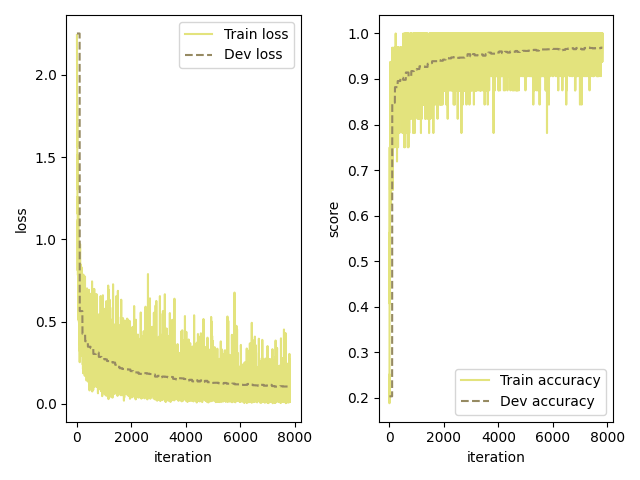 

## 2. CNN
### 2.1 Conv2D
*   **输入**: $\mathbf{X} \in \mathbb{R}^{\text{batch} \times \text{in\_channels} \times H \times W}$
*   **卷积核**: $\mathbf{W} \in \mathbb{R}^{\text{out\_channels} \times \text{in\_channels} \times \text{kernel\_size} \times \text{kernel\_size}}$
*   **偏置**: $\mathbf{b} \in \mathbb{R}^{\text{out\_channels} \times 1}$
*   **输出**: $\mathbf{Y} \in \mathbb{R}^{\text{batch} \times \text{out\_channels} \times H_{out} \times W_{out}}$
*   **步长**:  $= s$
*   **损失函数**:  \in \mathbb{R}$ (标量)

#### 2.1.1 向前传播

输入是一批图像，形状为 $N \times C_{in} \times H \times W$，分别表示样本数、输入通道数、高度、宽度。卷积核的形状是 $C_{out} \times C_{in} \times k \times k$，分别表示输出通道数、输入通道数、卷积核高度、卷积核宽度。

对于每个输出通道 $c_{out}$，每个输出位置 $(h, w)$，计算方式为：取出输入中以 $(h \cdot s, w \cdot s)$ 为起点的 $k \times k$ 窗口，和卷积核逐元素相乘再求和，最后加上偏置。用公式表示就是：

$$\mathbf{Y}_{n,c_{out},h,w} = \sum_{c_{in}=0}^{C_{in}-1} \sum_{i=0}^{k-1} \sum_{j=0}^{k-1} \mathbf{W}_{c_{out},c_{in},i,j} \cdot \mathbf{X}_{n,c_{in},h \cdot s+i,w \cdot s+j} + \mathbf{b}_{c_{out}}$$

其中 $s$ 是步长。比如输入是 $28 \times 28$，卷积核是 $5 \times 5$，步长为 1，那么输出就是 $24 \times 24$。计算公式为：

$$H_{out} = \left\lfloor \frac{H - k}{s} \right\rfloor + 1, \quad W_{out} = \left\lfloor \frac{W - k}{s} \right\rfloor + 1$$

#### 2.1.2 反向传播

#### 2.1.2 反向传播

为简化推导，我们基于 Im2Col 展开后的矩阵形式进行。前向传播可写为：

$$\mathbf{Y}_{col} = \mathbf{W}_{col} \cdot \mathbf{X}_{col}$$

其中：
- $\mathbf{X}_{col} \in \mathbb{R}^{(C_{in} \cdot k^2) \times (N \cdot H_{out} \cdot W_{out})}$ 为 Im2Col 展开后的输入矩阵
- $\mathbf{W}_{col} \in \mathbb{R}^{C_{out} \times (C_{in} \cdot k^2)}$ 为展开后的权重矩阵
- $\mathbf{Y}_{col} \in \mathbb{R}^{C_{out} \times (N \cdot H_{out} \cdot W_{out})}$ 为输出矩阵（展开形式）

反向传播时，上游传回的梯度为 $\frac{\partial L}{\partial \mathbf{Y}_{col}}$，形状与 $\mathbf{Y}_{col}$ 相同。需要计算三个梯度。

**1. 权重梯度 $\frac{\partial L}{\partial \mathbf{W}_{col}}$**

由矩阵乘法求导法则——对 $\mathbf{Y}_{col} = \mathbf{W}_{col} \cdot \mathbf{X}_{col}$，有 $\frac{\partial L}{\partial \mathbf{W}_{col}} = \frac{\partial L}{\partial \mathbf{Y}_{col}} \cdot \mathbf{X}_{col}^\top$。

直观验证：考虑单个元素 $Y_{pq} = \sum_{r} W_{pr} X_{rq}$，对 $W_{uv}$ 求导：

$$\frac{\partial Y_{pq}}{\partial W_{uv}} = \delta_{pu} \cdot X_{vq}$$

$$\frac{\partial L}{\partial W_{uv}} = \sum_{p,q} \frac{\partial L}{\partial Y_{pq}} \cdot \delta_{pu} \cdot X_{vq} = \sum_{q} \frac{\partial L}{\partial Y_{uq}} \cdot X_{vq}$$

这正是矩阵乘法 $\frac{\partial L}{\partial \mathbf{Y}_{col}} \cdot \mathbf{X}_{col}^\top$ 的第 $(u,v)$ 元素。故：

$$\boxed{\frac{\partial L}{\partial \mathbf{W}_{col}} = \frac{\partial L}{\partial \mathbf{Y}_{col}} \cdot \mathbf{X}_{col}^\top}$$

最后将 $\frac{\partial L}{\partial \mathbf{W}_{col}}$ reshape 回卷积核的形状 $(C_{out}, C_{in}, k, k)$。

**2. 偏置梯度 $\frac{\partial L}{\partial \mathbf{b}}$**

偏置 $\mathbf{b} \in \mathbb{R}^{C_{out}}$ 对每个输出通道加一个标量。前向传播时 $Y_{n,c_{out},h,w}$ 中 $\mathbf{b}_{c_{out}}$ 的系数始终为 1，因此：

$$\frac{\partial L}{\partial \mathbf{b}_{c_{out}}} = \sum_{n=1}^{N} \sum_{h=1}^{H_{out}} \sum_{w=1}^{W_{out}} \frac{\partial L}{\partial \mathbf{Y}_{n,c_{out},h,w}}$$

矩阵形式：

$$\boxed{\frac{\partial L}{\partial \mathbf{b}} = \sum_{n,h,w} \frac{\partial L}{\partial \mathbf{Y}_{n, :, h, w}}}$$

**3. 输入梯度 $\frac{\partial L}{\partial \mathbf{X}}$**

由矩阵乘法求导法则——对 $\mathbf{Y}_{col} = \mathbf{W}_{col} \cdot \mathbf{X}_{col}$，有 $\frac{\partial L}{\partial \mathbf{X}_{col}} = \mathbf{W}_{col}^\top \cdot \frac{\partial L}{\partial \mathbf{Y}_{col}}$。

直观验证：$\frac{\partial Y_{pq}}{\partial X_{uv}} = W_{pu} \cdot \delta_{vq}$，则

$$\frac{\partial L}{\partial X_{uv}} = \sum_{p,q} \frac{\partial L}{\partial Y_{pq}} \cdot W_{pu} \cdot \delta_{vq} = \sum_{p} W_{pu} \cdot \frac{\partial L}{\partial Y_{pv}}$$

$$\boxed{\frac{\partial L}{\partial \mathbf{X}_{col}} = \mathbf{W}_{col}^\top \cdot \frac{\partial L}{\partial \mathbf{Y}_{col}}}$$

最后通过 col2im 将 $\frac{\partial L}{\partial \mathbf{X}_{col}}$ 从展开形式还原为原来的图像形状 $(N, C_{in}, H, W)$。由于相邻卷积窗口存在重叠，同一像素的梯度会被多个窗口贡献，需用 `np.add.at` 累加所有贡献。

#### 2.1.3 Im2Col 优化

卷积操作如果直接用四层循环实现（遍历样本、输出通道、输出高度、输出宽度），在 Python 里会非常慢。这是因为 Python 的循环速度很慢——每次迭代需要做类型检查、边界检查，而且没法用 CPU 的向量化指令。在本实验中，用循环实现时训练一轮要花十几分钟。

Im2Col 的思路是把卷积运算变成矩阵乘法。矩阵乘法是高度优化的运算，有专门的底层库（如 BLAS、MKL）实现，这些库利用 SIMD 指令、多级缓存、多线程等技术，速度比 Python 循环快几十倍。

具体做法分成四步：

**第一步：把输入图像展开成矩阵**

以本实验为例，输入是一张 $28 \times 28$ 的单通道图像，卷积核是 $5 \times 5$，步长为 1，输出是 $24 \times 24$。

首先考虑输入图像上有多少个 $5 \times 5$ 的窗口。输出大小是 $24 \times 24$，所以一共有 $24 \times 24 = 576$ 个窗口。每个窗口包含 $5 \times 5 = 25$ 个像素。

把这 576 个窗口每个都拉直成一个 25 维的列向量，横着排在一起，就得到矩阵 $\mathbf{X}_{col}$，大小是 $25 \times 576$。每一列是一个窗口的 25 个像素值。

**第二步：把卷积核展开成矩阵**

本实验有 32 个输出通道，每个通道的卷积核都是 $5 \times 5 = 25$ 个参数。把 32 个卷积核排成 32 行，每行 25 个数，得到矩阵 $\mathbf{W}_{col}$，大小是 $32 \times 25$。每一行就是一个输出通道的卷积核。

**第三步：做矩阵乘法**

原来的卷积运算现在变成了一个简单的矩阵乘法：

$$\mathbf{Y}_{col} = \mathbf{W}_{col} \cdot \mathbf{X}_{col}$$

$\mathbf{W}_{col}$ 是 $32 \times 25$，$\mathbf{X}_{col}$ 是 $25 \times 576$，乘出来的 $\mathbf{Y}_{col}$ 是 $32 \times 576$。每一行对应一个输出通道，每一列对应一个输出位置。

最后把 $\mathbf{Y}_{col}$ reshape 成 $(N, 32, 24, 24)$ 的形状，就得到了和直接用循环完全一样的结果。

**第四步：反向传播也用矩阵乘法**

反向传播时，输出梯度 $\frac{\partial L}{\partial \mathbf{Y}}$ 的形状是 $(N, 32, 24, 24)$，先 reshape 成 $32 \times 576$ 的矩阵。然后用 $\mathbf{W}_{col}$ 的转置（$25 \times 32$）去乘，得到 $25 \times 576$ 的矩阵，这就是输入梯度的展开形式：

$$\frac{\partial L}{\partial \mathbf{X}_{col}} = \mathbf{W}_{col}^\top \cdot \frac{\partial L}{\partial \mathbf{Y}_{col}}$$

最后通过 col2im 操作，把这个 $25 \times 576$ 的矩阵还原成 $(N, 1, 28, 28)$ 的梯度。

这里有一个关键细节：相邻的窗口是有重叠的。比如输出位置 $(0,0)$ 的窗口是输入的第 0~4 行、0~4 列，输出位置 $(0,1)$ 的窗口是输入的第 0~4 行、1~5 列——它们共享了第 0~4 行、1~4 列这个区域。所以同一个输入像素可能属于多个窗口，在反向传播时，这个像素的梯度会被多个窗口贡献。我用 `np.add.at` 来把这些贡献累加起来，确保每个像素的梯度是所有相关窗口的总和。

**Im2Col 的代价**

展开后的矩阵比原始图像大很多。本实验中，原始输入是 $28 \times 28 = 784$ 个值，展开后是 $25 \times 576 = 14400$ 个值，大了约 18 倍。不过 MNIST 的图片很小，这个内存开销完全可以接受。如果是大尺寸图像（如 ImageNet 的 $224 \times 224$），展开后的内存开销就很可观了，可能需要用更高效的实现方式（如直接调用 cuDNN）。

#### 2.1.4 He 初始化

权重初始化看起来只是个细节，实际上对训练能否成功有决定性的影响。

**权重太大会怎样？**

假设我们用均值为 0、标准差为 1.0 的正态分布随机初始化所有权重。输入图像的像素值是 0 到 1 之间（归一化后）。第一层卷积有 1 个输入通道，卷积核大小是 $5 \times 5$，所以有 25 个连接。每个权重约为 1.0。

当 25 个输入（约 0~1）和 25 个权重（约 1.0）相乘再相加时，结果的标准差大约是 $\sqrt{25} = 5$。也就是说输出的值大致在 -10 到 10 之间。经过 ReLU 激活函数后，负值被截断为 0，正值保留，输出大约在 0 到 10 之间。

这看起来问题不大。但到了下一层（Flatten 后的全连接层），输入变成了 $32 \times 24 \times 24 = 18432$ 个，每个权重也约 1.0。输出标准差大约是 $\sqrt{18432} \approx 136$。经过 ReLU 后，输出在 0 到几百之间。再往后传，数值越来越大，最终 loss 变成无穷大（nan）。这就是梯度爆炸。

**权重太小会怎样？**

反过来，如果权重太小（比如标准差 0.001），那么第一层的输出只有 0.01 左右的量级。经过 ReLU 后，很多神经元输出接近 0，梯度也接近 0。信号在层层传播中越来越弱，最终模型完全学不动。这就是梯度消失。

**He 初始化怎么解决？**

He 初始化的想法很直接：根据输入的连接数来调整权重的尺度，使得输出的方差和输入的方差差不多大。这样信号既不会放大也不会衰减。

具体做法是，对于有 $D$ 个输入连接的层（卷积层中 $D = C_{in} \times k \times k$），把权重采样自均值为 0、标准差为 $\sqrt{2/D}$ 的正态分布：

$$\mathbf{W} \sim \mathcal{N}\left(0, \sqrt{\frac{2}{C_{in} \cdot k^2}}\right)$$

为什么是 $\sqrt{2/D}$ 而不是 $\sqrt{1/D}$？因为 ReLU 会把一半的输出变成 0。如果不补偿这个截断效应，输出的方差会变成输入方差的一半，信号会逐渐衰减。乘以 2 就是为了弥补 ReLU 造成的损失。

**在本实验中的效果**

第一层卷积：$C_{in}=1$，$k=5$，所以 $D = 1 \times 25 = 25$。He 初始化的标准差为 $\sqrt{2/25} \approx 0.283$。

实际训练中，使用 He 初始化后，loss 从约 2.3 平稳下降，训练全程没有出现 nan。如果换成标准差 1.0 的初始化，loss 在几步之内就变成 nan 了。这说明对于 ReLU 激活函数，He 初始化不是可选的——它几乎是一个必需品。


#### 2.1.5 Flatten

In [ ]:
class Flatten(Layer):
    def __init__(self) -> None:
        super().__init__()
        self.optimizable = False
        self.input_shape = None

    def __call__(self, X):
        return self.forward(X)

    def forward(self, X):
        self.input_shape = X.shape
        batch_size = X.shape[0]
        return X.reshape(batch_size, -1)

    def backward(self, grad):
        return grad.reshape(self.input_shape)

### 2.2 CNN model

In [ ]:
class Model_CNN(Layer):
    def __init__(self):
        super().__init__()
        self.layers = []

        self.layers.append(conv2D(in_channels=1, out_channels=32, kernel_size=5, stride=1))
        self.layers.append(ReLU())
        self.layers.append(Flatten())
        self.layers.append(Linear(in_dim=18432, out_dim=10))

    
    def __call__(self, X):
        return self.forward(X)

    def forward(self, X):
        for layer in self.layers:
            X = layer.forward(X)
        return X

    def backward(self, loss_grad):
        for layer in reversed(self.layers):
            loss_grad = layer.backward(loss_grad)
        return loss_grad
    
    def save_model(self, save_path):
        param_list = []
        for layer in self.layers:
            if layer.optimizable:
                p = {
                    'W': layer.params['W'], 
                    'b': layer.params['b'], 
                    'weight_decay': layer.weight_decay, 
                    'lambda': layer.weight_decay_lambda
                }
                param_list.append(p)
        
        with open(save_path, 'wb') as f:
            pickle.dump(param_list, f)

    def load_model(self, model_path):
        with open(model_path, 'rb') as f:
            param_list = pickle.load(f)
        
        optimizable_idx = 0
        for layer in self.layers:
            if layer.optimizable:
                layer.params['W'] = param_list[optimizable_idx]['W']
                layer.params['b'] = param_list[optimizable_idx]['b']
                layer.weight_decay = param_list[optimizable_idx]['weight_decay']
                layer.weight_decay_lambda = param_list[optimizable_idx]['lambda']
                optimizable_idx += 1

### 2.3 Modification
$runner.py$进行一些调整，否则因为CNN计算量太大，每次都要去验证集上验证一下，访存时间大，训练会很慢

In [ ]:
"""
dev_score, dev_loss = self.evaluate(dev_set)
self.dev_scores.append(dev_score)
self.dev_loss.append(dev_loss)
"""
if iteration % log_iters == 0:
    dev_score, dev_loss = self.evaluate(dev_set)
    self.dev_scores.append(dev_score)
    self.dev_loss.append(dev_loss)
else:
    self.dev_scores.append(self.dev_scores[-1] if self.dev_scores else 0)
    self.dev_loss.append(self.dev_loss[-1] if self.dev_loss else 0)

### 2.4 Compare the CNN with the MLP

CNN 在 MNIST 上的表现优于 MLP，核心原因在于二者处理图像的方式存在本质差异。

MLP 将 $28 	imes 28$ 的图像拉直为 784 维向量，每个隐藏层神经元与全部 784 个输入相连。这种方式存在两个明显问题：

第一，**破坏了像素的空间关系**。图像中相邻的像素在拉直后的向量中可能相距很远。例如，第一行最后一个像素与第二行第一个像素在图像中是上下相邻的，但在向量中相隔 28 个位置。MLP 无法感知这种空间邻近性，只能记住特定位置的像素值组合。

第二，**参数量过大**。本实验中 MLP 的第一层有 $784 	imes 600 = 470400$ 个参数，总计约 47 万个参数。过多的参数不仅增加计算开销，还容易导致过拟合——模型可能记住训练集中的噪声，而非学习通用的特征。

CNN 采用 $5 	imes 5$ 的卷积核在图像上滑动，每次仅处理局部区域。这种方式有以下优势：

第一，**保留空间关系**。卷积核内的 25 个像素在图像中是真实相邻的，CNN 能够自然地捕捉局部特征，如边缘、纹理和拐角。

第二，**减少参数量**。每个卷积核仅有 25 个参数，且同一卷积核在图像所有位置共享。本实验中 CNN 的参数量约为 18.5 万，比 MLP 减少约 60%。

第三，**平移不变性**。由于卷积核在整幅图像上滑动，无论数字出现在左上角还是右下角，同一特征检测器都能识别。MLP 则需要在不同位置分别学习，效率低下。

第四，**层次化特征提取**。CNN 通过多层卷积逐步构建特征表示：底层检测简单特征（如线条、边缘），中层组合为形状，高层形成完整的数字轮廓。MLP 缺乏这种层次化结构，难以有效提取图像的层次化表示。

实验结果验证了这一分析：

| Setting | Best Dev Acc | Test Acc |
|---------|--------------|----------|
| MLP Baseline | 0.9689       | 0.9718   |
| CNN     | 0.9811       | 0.9837   |

CNN 的验证集准确率比 MLP 高 1.22%，测试集高 1.19%。错误率从 2.82% 降至 1.63%，降低了约 42%。这表明 CNN 不仅拟合能力更强，泛化性能也更优。

![Figure_2.png](attachment:Figure_2.png)


In [ ]:
lr_list = [0.1, 0.01, 0.001]
results = []

print(f"{'Learning Rate':<15} | {'Best Dev Accuracy':<15}")
print("-" * 35)

for lr in lr_list:
    linear_model = nn.models.Model_MLP([train_imgs.shape[-1], 600, 10], 'ReLU')
    
    optimizer = nn.optimizer.SGD(init_lr=lr, model=linear_model)
    loss_fn = nn.op.MultiCrossEntropyLoss(model=linear_model, max_classes=train_labs.max()+1)
    
    runner = nn.runner.RunnerM(linear_model, optimizer, nn.metric.accuracy, loss_fn)
    
    print(f"\n[Training]MLP_{lr}")
    runner.train([train_imgs, train_labs], [valid_imgs, valid_labs], num_epochs=5, log_iters=100, save_dir=f'./saved_models/MLP_Lr_{lr}')
    
    _, axes = plt.subplots(1, 2)
    plot(runner, axes)
    plt.show()

    results.append((lr, runner.best_score))
    print(f"[Done] LR: {lr}, Best Acc: {runner.best_score:.4f}")

| Learning Rate | Best Dev Acc | Test Acc |
|---------------|--------------|----------|
| 0.1           | 0.9744       | 0.9774   |
| MLP Baseline(0.06) | 0.9689       | 0.9718   |
| 0.01          | 0.9357       | 0.9372   |
| 0.001         | 0.8777       | 0.8858   |

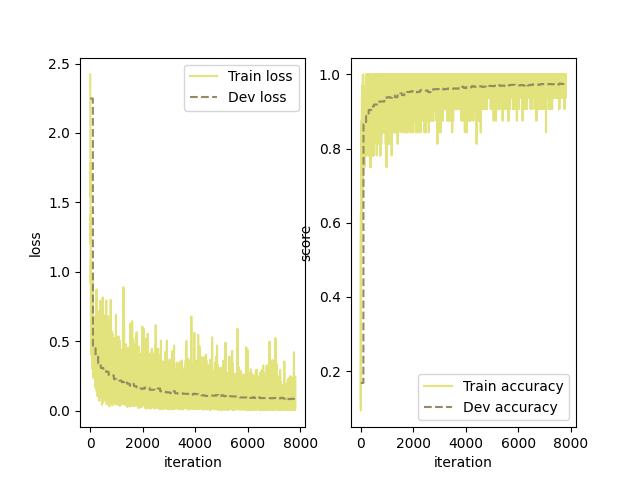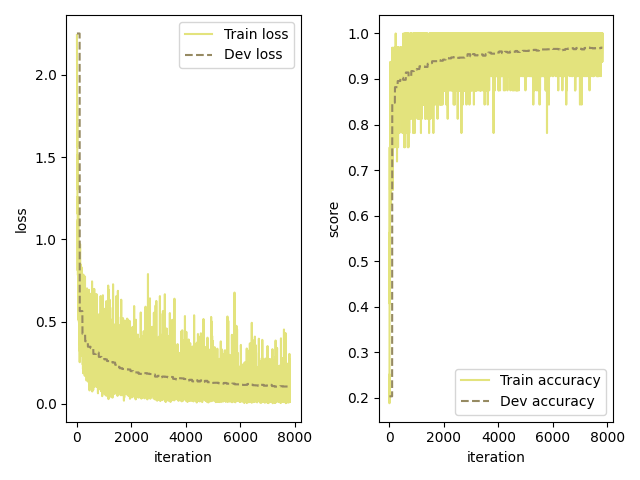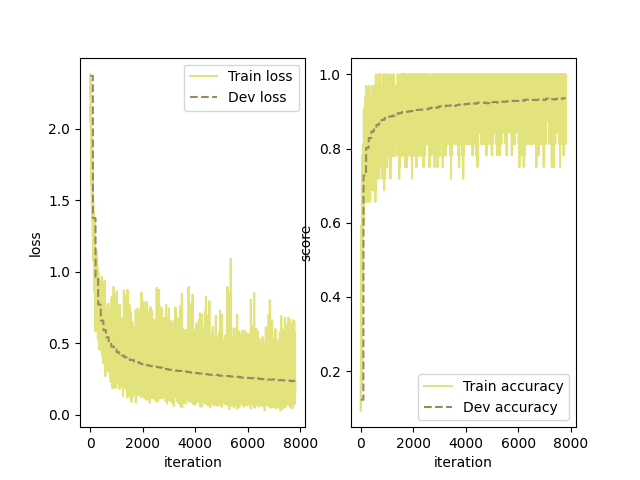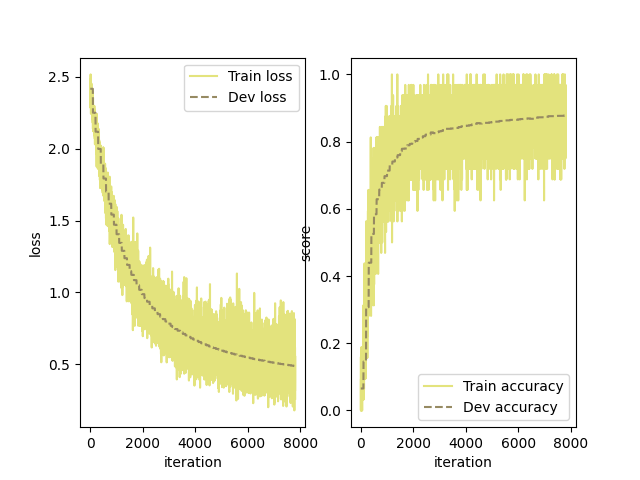

### 3.1 Optimization


#### 3.1.1 different learning rate settings


#### 3.1.2 learning rate scheduling

In [ ]:
class MultiStepLR(scheduler):
    def __init__(self, optimizer, milestones, gamma=0.1) -> None:
        super().__init__(optimizer)
        self.milestones = set(milestones) 
        self.gamma = gamma

    def step(self) -> None:
        self.step_count += 1
        if self.step_count in self.milestones:
            self.optimizer.init_lr *= self.gamma
            print(f"MultiStepLR: Learning rate reduced to {self.optimizer.init_lr} at step {self.step_count}")

class ExponentialLR(scheduler):
    def __init__(self, optimizer, gamma=0.999) -> None:
        super().__init__(optimizer)
        self.gamma = gamma

    def step(self) -> None:
        self.step_count += 1
        self.optimizer.init_lr *= self.gamma

| Learning Rate Strategy | Best Dev Acc | Test Acc |
|------------------------|--------------|----------|
| StepLR                 | 0.7802       | 0.7919   |
| MultiStepLR            | 0.9501       | 0.9521   |
| ExponentialLR          | 0.9274       | 0.9344   |

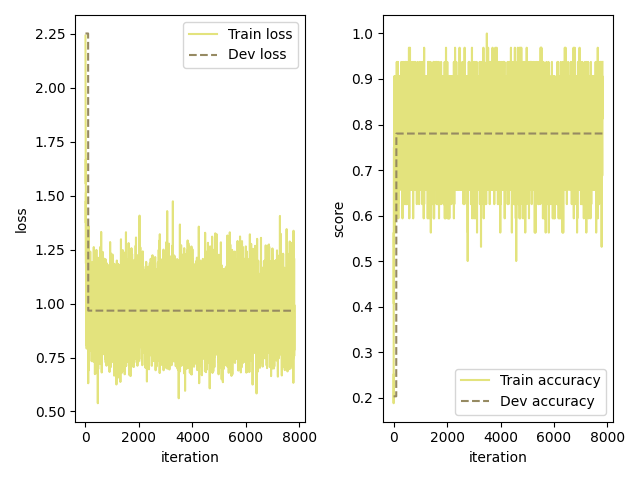 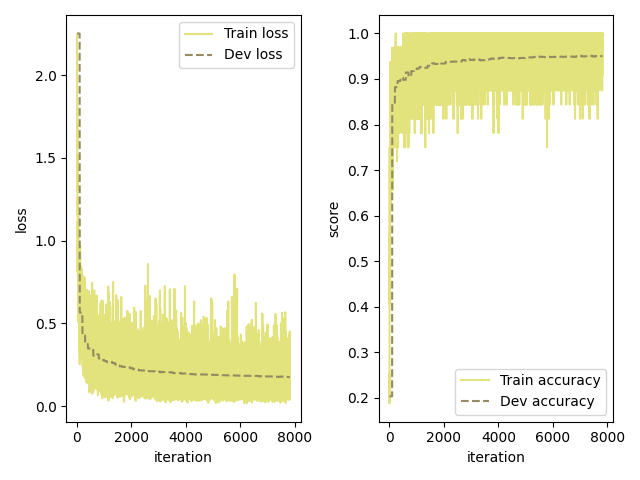 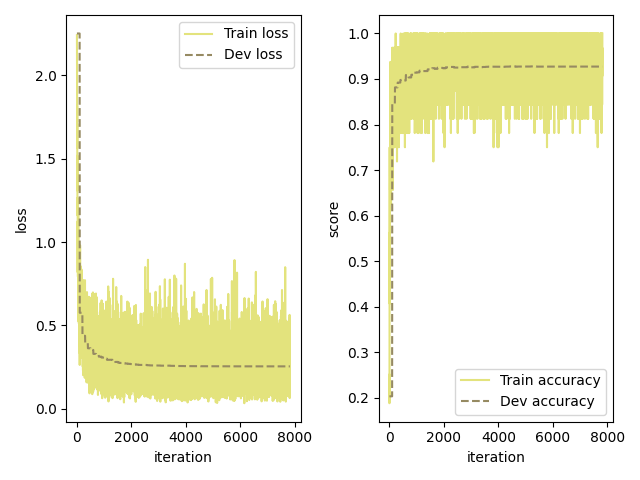

### 3.2 Error Analysis and Visualization
#### 3.2.1 confusion matrix

In [ ]:
# weight_visualization.py

import mynn as nn
import numpy as np
from struct import unpack
import gzip
import matplotlib.pyplot as plt
import pickle


model = nn.models.Model_MLP()
model.load_model(r'.\saved_models\MLP_baseline.pickle')

test_images_path = r'.\dataset\MNIST\t10k-images-idx3-ubyte.gz'
test_labels_path = r'.\dataset\MNIST\t10k-labels-idx1-ubyte.gz'

with gzip.open(test_images_path, 'rb') as f:
    magic, num, rows, cols = unpack('>4I', f.read(16))
    test_imgs = np.frombuffer(f.read(), dtype=np.uint8).reshape(num, 28*28)
    
with gzip.open(test_labels_path, 'rb') as f:
    magic, num = unpack('>2I', f.read(8))
    test_labs = np.frombuffer(f.read(), dtype=np.uint8)

test_imgs = test_imgs / test_imgs.max()

logits = model(test_imgs)
preds = np.argmax(logits, axis=-1)

print(f"Test Accuracy: {nn.metric.accuracy(logits, test_labs):.4f}")

#confusion matrix 
def plot_confusion_matrix(y_true, y_pred, num_classes=10):
    cm = np.zeros((num_classes, num_classes), dtype=int)
    
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, cmap='Blues')
    
    for i in range(num_classes):
        for j in range(num_classes):
            text = ax.text(j, i, cm[i, j], ha="center", va="center", 
                          color="white" if cm[i, j] > cm.max()/2 else "black",
                          fontsize=10)
    
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_title('Confusion Matrix (MLP Baseline)', fontsize=14)
    ax.set_xticks(np.arange(num_classes))
    ax.set_yticks(np.arange(num_classes))
    ax.set_xticklabels([str(i) for i in range(num_classes)])
    ax.set_yticklabels([str(i) for i in range(num_classes)])
    
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.savefig(r'.\Figs\MLP_Figure\confusion_matrix.png', dpi=150)
    plt.show()
    
    return cm

print("\nConfusion Matrix")
cm = plot_confusion_matrix(test_labs, preds)

for i in range(10):
    total = cm[i].sum()
    correct = cm[i, i]
    error_rate = (total - correct) / total * 100
    print(f"Digit {i}: {correct}/{total} correct, Error rate: {error_rate:.2f}%")

#Misclassified Examples
def plot_misclassified_examples(images, labels, preds, num_examples=20):
    cm = np.zeros((10, 10), dtype=int)
    for t, p in zip(labels, preds):
        cm[t, p] += 1
    
    worst = max(range(10), key=lambda i: 1 - cm[i,i]/cm[i].sum() if cm[i].sum() > 0 else 0)
    
    cm[worst, worst] = 0
    confused = np.argmax(cm[worst])
    
    idx = np.where((labels == worst) & (preds == confused))[0]
    selected = np.random.choice(idx, min(num_examples, len(idx)), replace=False)
    
    rows = (len(selected) + 4) // 5
    fig, axes = plt.subplots(rows, 5, figsize=(12, 2.5*rows))
    for i, ax in enumerate(axes.flat):
        if i < len(selected):
            ax.imshow(images[selected[i]].reshape(28,28), cmap='gray')
            ax.set_title(f'{worst}->{confused}')
        ax.axis('off')
    
    plt.tight_layout()
    plt.savefig(r'.\Figs\MLP_Figure\misclassified.png', dpi=150)
    plt.show()

print("\nMisclassified Examples")
plot_misclassified_examples(test_imgs, test_labs, preds, num_examples=20)

| Digit | Correct / Total | Error Rate |
|-------|-----------------|------------|
| 0     | 970 / 980       | 1.02%      |
| 1     | 1124 / 1135     | 0.97%      |
| 2     | 1000 / 1032     | 3.10%      |
| 3     | 980 / 1010      | 2.97%      |
| 4     | 960 / 982       | 2.24%      |
| 5     | 854 / 892       | 4.26%      |
| 6     | 939 / 958       | 1.98%      |
| 7     | 998 / 1028      | 2.92%      |
| 8     | 931 / 974       | 4.41%      |
| 9     | 962 / 1009      | 4.66%      |
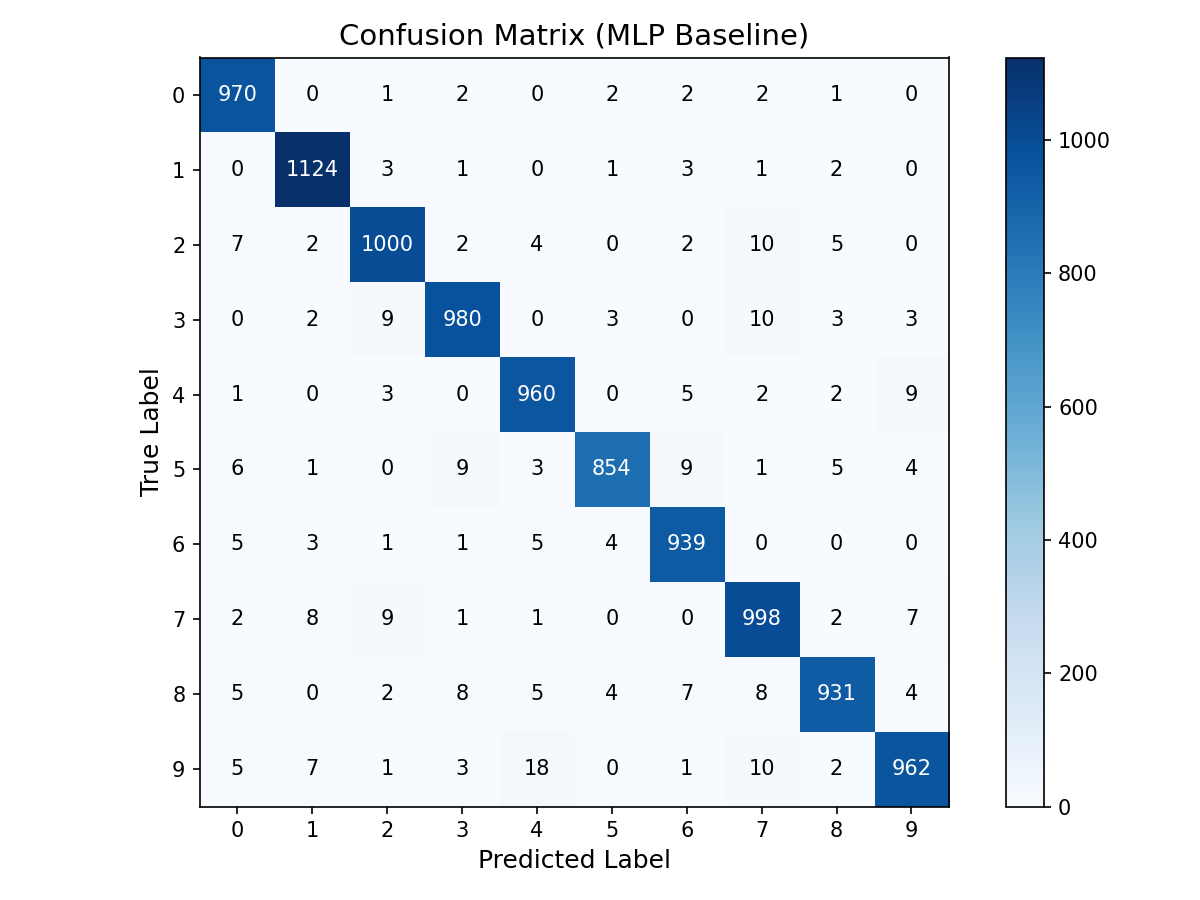

#### 3.2.2 misclassified examples

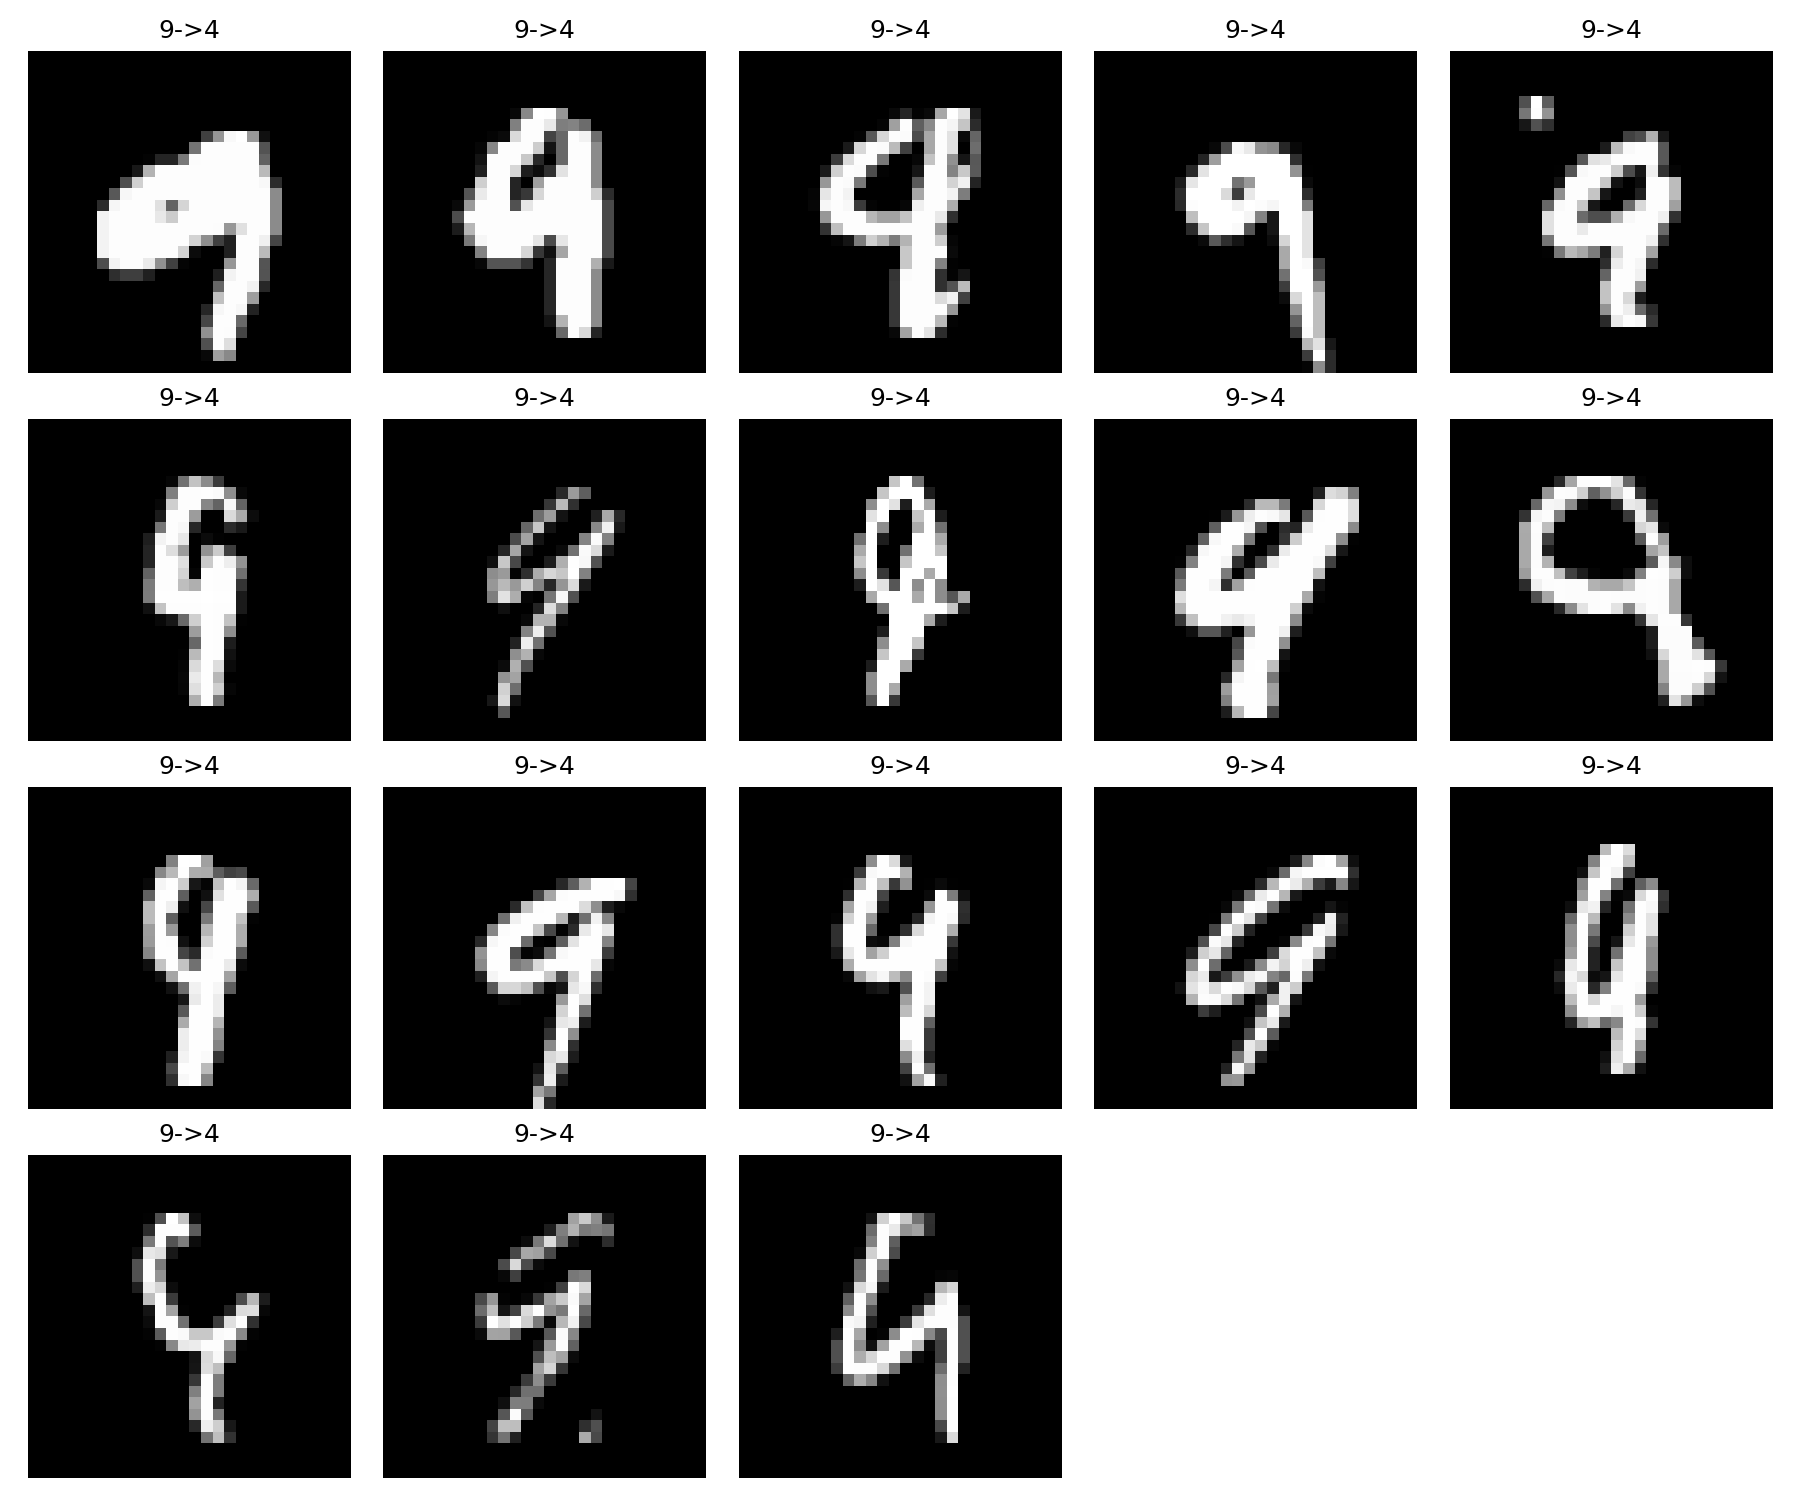

#### 3.2.3 Analysis

从混淆矩阵和错误分类样本中可以观察到以下现象：

**最容易混淆的数字对**

从混淆矩阵的对角线外元素来看，最常见的错误是 5 被错认成 3。观察这两个数字的形状：5 和 3 的上半部分都是一条向右上方弯曲的弧线，中间都有一条横线。如果手写时 5 的左上角没有闭合好，或者横线位置偏高，看起来就跟 3 几乎一样了。

8 也容易被错认成 3 或 5。8 本来由上下两个圆圈组成，但如果写得比较潦草，两个圈连在一起了，就变成了一个扭曲的 3。如果上半部分比较圆、下半部分比较尖，又可能像 5。

9 被错认成 4 或 7 也很常见。9 的上半部分是一个圈，下面带一竖。如果圈写得不够圆，或者竖线偏左，看起来就像 4（左上角开口）。如果竖线写得很直很长，又可能像 7。反过来的情况也存在——如果 4 的左上角闭合了，或者右侧竖线和左侧连在了一起，看起来就像 9。

**错误率分布**

从每个数字的错误率来看：
- 错误率最高的数字是 5（4.26%）、8（4.41%）、9（4.66%）。这些数字的共同点是结构都比较复杂，包含曲线、横线、竖线多种元素，不同人的写法差异很大。
- 错误率最低的数字是 0（1.02%）和 1（0.97%）。结构最简单（一个圈、一条竖线），变形空间小。

**为什么会犯这些错误？**

主要原因有三个：

第一，某些数字的局部特征太像了。模型通过检测边缘、曲线等局部特征来分类。当两个数字共享某些特征组合时，模型就难以区分。比如"右上弧线加横线"这个特征组合同时出现在 5 和 3 上。

第二，手写风格差异太大。MNIST 来自很多不同的人，有人写 5 横线很短、有人写 7 中间加一横（欧洲写法）。训练集中这些变体的样本可能不够多，模型没见过就分不好。

第三，部分图片质量差。有些样本边缘模糊，特征不明显。比如一个模糊的 8，上下两个圈都不清晰，看起来就像一个被压扁的 3。

**改进方向**

基于这些分析，如果继续改进模型，可以尝试：

- 对训练图片做轻微的旋转、平移、缩放，让模型见到更多变形版本的同一个数字，提高对书写变体的适应能力。
- 增加卷积层数，提取更高级的特征（比如"上半圆加竖线"这种组合），有助于区分 9 和 4 这类容易混淆的数字。
- 让模型更关注区分性强的区域，比如区分 5 和 3 时重点看左上角是否闭合。
